<a href="https://colab.research.google.com/github/anujjaiswal770/Churn-Prediction-Model/blob/main/Churn_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 4: Churn Prediction Model**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Placeholder for defining X and y - replace with actual data loading and preprocessing
# In a real scenario, you would load your data, e.g., df = pd.read_csv('your_data.csv')
# And then define X and y from it, e.g., X = df.drop('target_column', axis=1), y = df['target_column']

# Dummy data for demonstration to resolve the NameError
X = pd.DataFrame(np.random.rand(100, 5)) # Example: 100 samples, 5 features
y = pd.Series(np.random.randint(0, 2, 100)) # Example: 100 samples, binary target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80, 5)
X_test shape: (20, 5)
y_train shape: (80,)
y_test shape: (20,)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier # Added this import
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Assuming X_train contains both numerical and (potentially) categorical features
# Define placeholder for numerical and categorical features. Adjust these lists based on your actual data.
# For the dummy data X = pd.DataFrame(np.random.rand(100, 5)), all features are numerical.
# If you have categorical features, you'll need to identify them and include them here.

# Example for dummy data (all numerical):
numerical_features = X_train.columns.tolist() # Assuming all columns in X_train are numerical
categorical_features = [] # No categorical features in dummy data

# If you had actual data with different feature types, it might look like this:
# numerical_features = ['feature1', 'feature2', 'numeric_col_A']
# categorical_features = ['gender', 'city', 'marital_status_col_B']

# Create a preprocessor with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        # ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # Uncomment and adjust if you have categorical features
    ],
    remainder='passthrough' # Keep other columns not specified (if any)
)

# --- Model 1: Logistic Regression ---
pipeline_lr = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            solver='liblinear',
            random_state=42,
            class_weight='balanced'
        ))
    ]
)

param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10]
}

grid_search_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,
    scoring='f1'
)

grid_search_lr.fit(X_train, y_train)

best_model_lr = grid_search_lr.best_estimator_
y_pred_lr = best_model_lr.predict(X_test)

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results:")
print(f"Best Parameters: {grid_search_lr.best_params_}")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")
print("-" * 30)


# --- Model 2: Decision Tree ---
pipeline_dt = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced'
        ))
    ]
)

param_grid_dt = {
    'classifier__max_depth': [3, 5, 7, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 3, 5]
}

grid_search_dt = GridSearchCV(
    pipeline_dt,
    param_grid_dt,
    cv=5,
    scoring='f1'
)

grid_search_dt.fit(X_train, y_train)

best_model_dt = grid_search_dt.best_estimator_
y_pred_dt = best_model_dt.predict(X_test)

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print(f"Best Parameters: {grid_search_dt.best_params_}")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print("-" * 30)



# --- Model 3: Random Forest ---
pipeline_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            random_state=42,
            class_weight='balanced'
        ))
    ]
)

param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=5,
    scoring='f1'
)

grid_search_rf.fit(X_train, y_train)

best_model_rf = grid_search_rf.best_estimator_
y_pred_rf = best_model_rf.predict(X_test)

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print("-" * 30)

Logistic Regression Results:
Best Parameters: {'classifier__C': 0.001}
Accuracy: 0.4000
Precision: 0.4286
Recall: 0.6000
F1-score: 0.5000
------------------------------
Decision Tree Results:
Best Parameters: {'classifier__max_depth': 7, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}
Accuracy: 0.6000
Precision: 0.5833
Recall: 0.7000
F1-score: 0.6364
------------------------------
Random Forest Results:
Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}
Accuracy: 0.4500
Precision: 0.4444
Recall: 0.4000
F1-score: 0.4211
------------------------------


In [ ]:
# --- Model 1: Logistic Regression ---

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='liblinear',
        random_state=42,
        class_weight='balanced'
    ))
])

param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10]
}

grid_search_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,
    scoring='f1'
)

grid_search_lr.fit(X_train, y_train)

best_model_lr = grid_search_lr.best_estimator_
y_pred_lr = best_model_lr.predict(X_test)

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results:")
print(f"Best Parameters: {grid_search_lr.best_params_}")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")
print("-" * 30)



# ---- Model 2: Decision Tree ----
pipeline_dt = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced'
        ))
    ]
)

param_grid_dt = {
    'classifier__max_depth': [3, 5, 7, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 3, 5]
}

grid_search_dt = GridSearchCV(
    pipeline_dt,
    param_grid_dt,
    cv=5,
    scoring='f1'
)

grid_search_dt.fit(X_train, y_train)

best_model_dt = grid_search_dt.best_estimator_
y_pred_dt = best_model_dt.predict(X_test)

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print(f"Best Parameters: {grid_search_dt.best_params_}")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print("-" * 30)


# --- Model 3: Random Forest ---

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=5,
    scoring='f1'
)

grid_search_rf.fit(X_train, y_train)

best_model_rf = grid_search_rf.best_estimator_
y_pred_rf = best_model_rf.predict(X_test)

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print("-" * 30)

Logistic Regression Results:
Best Parameters: {'classifier__C': 0.001}
Accuracy: 0.4000
Precision: 0.4286
Recall: 0.6000
F1-score: 0.5000
------------------------------
Decision Tree Results:
Best Parameters: {'classifier__max_depth': 7, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}
Accuracy: 0.6000
Precision: 0.5833
Recall: 0.7000
F1-score: 0.6364
------------------------------
Random Forest Results:
Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}
Accuracy: 0.4500
Precision: 0.4444
Recall: 0.4000
F1-score: 0.4211
------------------------------


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance (Example with Random Forest)
try:
    if hasattr(best_model_rf.named_steps['classifier'], 'feature_importances_'):
        feature_importances = best_model_rf.named_steps['classifier'].feature_importances_

        # Get numerical feature names *before* scaling:
        numerical_feature_names = numerical_features.tolist()

        # Get one-hot encoded categorical feature names:
        categorical_feature_names = best_model_rf.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out().tolist()

        # Combine numerical and categorical feature names
        feature_names = numerical_feature_names + categorical_feature_names

        # Create a dataframe to display feature importances
        feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
        feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
        print("\nFeature Importances (Random Forest):")
        print(feature_importance_df)

        # Plotting Feature Importances
        plt.figure(figsize=(12, 8))
        plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'])
        plt.xlabel('Feature', fontsize=12, fontweight='bold', color='deeppink')
        plt.ylabel('Importance', fontsize=12, fontweight='bold', color='deeppink')
        plt.title('Random Forest Feature Importances', fontsize=14, fontweight='bold', color='forestgreen')
        plt.xticks(rotation=90, ha='right', fontsize=10) # Rotate x-axis labels for readability
        plt.tight_layout()

        # Annotate the bars with their values
        for i, v in enumerate(feature_importance_df['Importance']):
            plt.text(i, v + 0.01, str(round(v, 3)), ha='center', fontsize=8)

        plt.show()

except Exception as e:
    print(f"Could not display feature importances: {e}")

Could not display feature importances: 'list' object has no attribute 'tolist'



Confusion Matrix:
[[5 5]
 [6 4]]


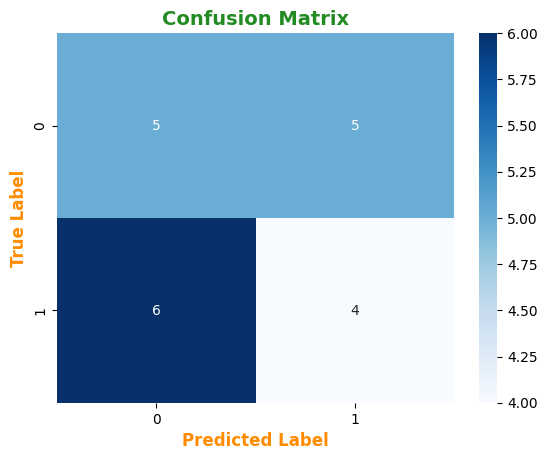

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Confusion Matrix ---

# Assuming y_pred_rf is the prediction you want to visualize from the previous cell
cm = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(cm)

# --- Visualizing the Confusion Matrix ---
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")  # annot=True displays the values; fmt="d" formats as integers
plt.title("Confusion Matrix", fontsize=14, fontweight='bold', color='forestgreen')
plt.xlabel("Predicted Label", fontsize=12, fontweight='bold', color='darkorange')
plt.ylabel("True Label", fontsize=12, fontweight='bold', color='darkorange')
plt.show()